In [67]:
import pandas as pd
import numpy as np
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

In [28]:
df = pd.read_csv('dataset.csv')
df  = df.sample(frac=1, random_state=55).reset_index(drop=True)

In [29]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [30]:
X.shape

(207, 60)

In [31]:
Y.shape

(207,)

In [32]:
Y = Y.replace({'R':0, 'M':1})

In [33]:
X = X.values
Y = Y.values
X = X.astype('float32')
Y = Y.astype('float32')

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=55)

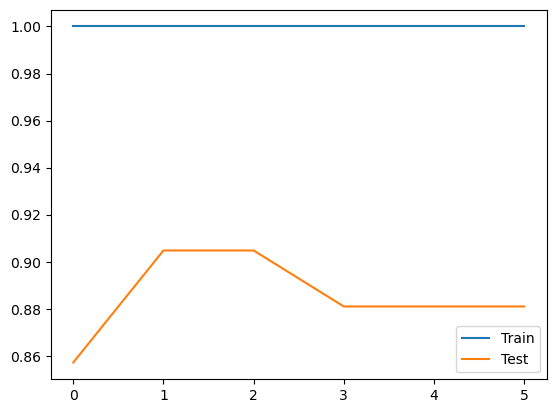

In [66]:
n_enum_list = [500, 1000, 1500, 1650, 1800, 2000]

acc_train = []
acc_test = []

for n_enum in n_enum_list:

    #try max_depth = 2,3,4 
    #try learning_rate = 0.01, 0.005, 0.001, 0.0005
        
    model = XGBClassifier(n_estimators=n_enum,
                          max_depth=3,
                          learning_rate=0.01,
                          eval_metric='logloss',
                          tree_method='hist',
                          random_state=55
                         )
    
    model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)
    
    acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.show()

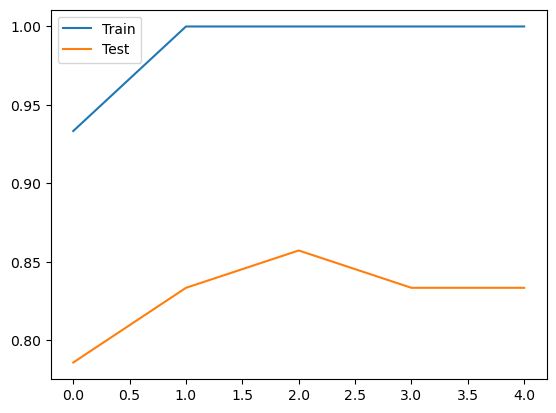

In [62]:
#from above we will try n_estimators= 1000, 1500, 1750

depth_list = [1, 2, 3, 4, 6]

acc_train = []
acc_test = []

for d in depth_list:

    #try alpha = 0.01, 0.005, 0.001, 0.0005
        
    model = XGBClassifier(n_estimators=1500,
                          max_depth=d,
                          learning_rate=0.005,
                          eval_metric='logloss',
                          tree_method='hist',
                          random_state=55
                         )
    
    model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)
    
    acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.show()

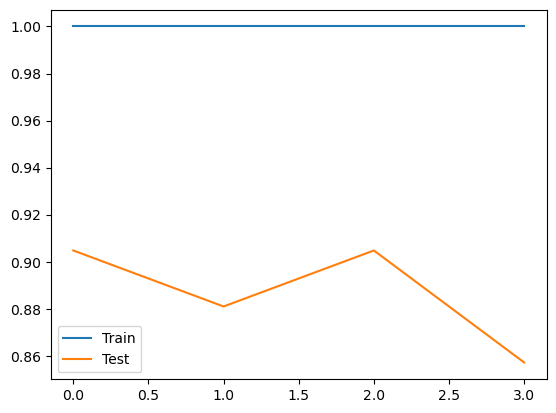

In [64]:
#from above we will try n_estimators=1000, 1500
#from above will try max_depth = 2,3

alpha_list = [0.1, 0.05, 0.01, 0.005]

acc_train = []
acc_test = []


for alpha in alpha_list:

    model = XGBClassifier(n_estimators=1500,
                          max_depth=3,
                          learning_rate=alpha,
                          eval_metric='logloss',
                          tree_method='hist',
                          random_state=55
                         )
    
    model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)
    
    acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.show()

In [65]:
#from above max_depth = 3 is best
#from above n_estimators = 1000, 1500 gives similar result so set it to 1250
#from above alpha = 0.1 and 0.01 are best

model = XGBClassifier(n_estimators=1250, max_depth=3, learning_rate=0.01, tree_method='hist', eval_metric='logloss', random_state=55)

model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)

print(f"Training set Accuracy: {accuracy_score(model.predict(X_train), Y_train)*100: .2f}")
print(f"Test set Accuracy: {accuracy_score(model.predict(X_test), Y_test)*100: .2f}")

Training set Accuracy:  100.00
Test set Accuracy:  90.48


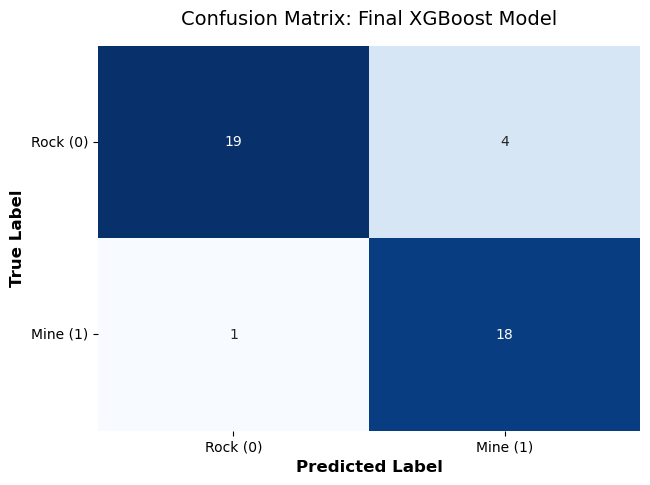

In [68]:
predictions = model.predict(X_test)
cm = confusion_matrix(Y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rock (0)', 'Mine (1)'], 
            yticklabels=['Rock (0)', 'Mine (1)'])

plt.title('Confusion Matrix: Final XGBoost Model', pad=15, fontsize=14)
plt.xlabel('Predicted Label', weight='bold', fontsize=12)
plt.ylabel('True Label', weight='bold', fontsize=12)

plt.yticks(rotation=0) 
plt.show()